In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


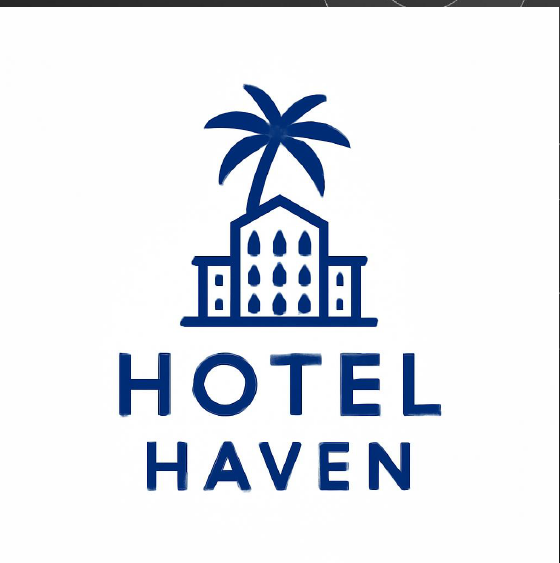

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/drive/MyDrive/Hotel Haven.png", width=260))


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Hotel Haven – Booking Cancellation Analysis**

## Predictive Modelling & Business Insights

**Author:** Lauretta Oghenevurie  
**Email:** laureldebelle@gmail.com  

---

## Skills Demonstrated
- Python (Pandas, NumPy, Scikit-learn)
- Exploratory Data Analysis (EDA)
- Feature Engineering & Data Preprocessing
- Supervised Machine Learning (Classification)
- Model Evaluation & Comparison
- Business Insight Translation & Decision Support

---

## Project Sections

1. **Business Background**
2. **Project Objectives and Key Business Questions**
3. **Data Overview**
4. **Data Cleaning and Preparation**
5. **Feature Engineering and Preprocessing**
6. **Predictive Modelling**
   - Logistic Regression  
   - Decision Tree  
   - Random Forest  
   - Gradient Boosting  
7. **Key Business Questions Answered**
8. **Conclusion**
9. **Limitations**
10. **Future Work**

---



# **1. BUSINESS BACKGROUND**

Hotel Haven is experiencing high booking cancellations, leading to revenue loss and inefficient resource allocation. The business requires insights into booking patterns and a predictive approach to identify bookings at risk of cancellation early, enabling proactive retention strategies.

# **2. PROJECT OBJECTIVES AND KEY BUSINESS QUESTIONS**

A. What booking and customer characteristics influence cancellation behaviour?

B. Can booking outcomes be predicted reliably using historical data?

C. Which factors most strongly drive cancellation risk?

D. How can these insights be translated into actions to reduce cancellations and improve planning?

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/booking.csv')

# **3. DATA OVERVIEW**

The dataset contains booking-level records with customer, booking, stay and pricing features. The target variable is booking_status, indicating whether a booking was canceled.

In [ ]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [ ]:
df.shape

(36285, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

# **4. DATA CLEANING & PREPARATION**

The dataset was reviewed and cleaned to ensure consistency, interpretability, and suitability for supervised modelling. Low-frequency categorical levels were consolidated to improve model stability, redundant and intermediate columns were removed, and binary indicators were standardised where necessary. Date fields were validated and transformed into meaningful temporal features, and all remaining variables were verified for valid ranges and missing values. This process resulted in a clean, modelling-ready dataset.

# Target Validation & Encoding

Booking status is the outcome label for each booking. It has two classes: Canceled and Not_Canceled.
For modelling, it is encoded as: Canceled = 1 (event of interest) and Not_Canceled = 0.


In [ ]:
df['booking status'].value_counts()


,count
booking status,
Not_Canceled,24396
Canceled,11889


In [ ]:
df['booking status_encoded'] = df['booking status'].map({
    'Canceled': 1,
    'Not_Canceled': 0
})


In [ ]:
df['booking status'].unique()


array(['Not_Canceled', 'Canceled'], dtype=object)

In [ ]:
df[['booking status', 'booking status_encoded']].head()


,booking status,booking status_encoded
0,Not_Canceled,0
1,Not_Canceled,0
2,Canceled,1
3,Canceled,1
4,Canceled,1


In [ ]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,booking status_encoded
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled,0
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled,0
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled,1
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled,1
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled,1


# Feature Review & Validation

**Feature: Booking_ID**

Booking_ID is a unique identifier assigned to each booking record. It is used solely for record identification and traceability.



In [ ]:
df['Booking_ID'].nunique(), df.shape[0]


(36285, 36285)

Cleaning decision: Booking_ID uniquely identifies each booking and contains no duplicate values. It is retained for traceability but excluded from modelling, as it has no predictive value.

**Feature: Number of Adults**

This variable represents the number of adults included in a booking. It reflects booking size and may influence cancellation behaviour due to cost and commitment level.

In [ ]:
df['number of adults'].describe()


,number of adults
count,36285.000000
mean,1.844839
std,0.518813
min,0.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,4.000000


In [ ]:
df['number of adults'].value_counts().sort_index()


,count
number of adults,
0,139
1,7702
2,26110
3,2318
4,16


Cleaning decision: Number of adults contains a small number of records with a value of 0, which is not valid for hotel bookings. These records are assumed to represent single-adult bookings recorded incorrectly and are recoded to 1 adult to preserve data integrity.

In [ ]:
df.loc[df['number of adults'] == 0, 'number of adults'] = 1


In [ ]:
df['number of adults'].value_counts().sort_index()


,count
number of adults,
1,7841
2,26110
3,2318
4,16


**Feature: Number of Children**

This variable represents the number of children included in a booking. It reflects the presence of dependents in the travel party and may influence cancellation behaviour due to changes in travel plans, accommodation needs and booking flexibility.

In [ ]:
df['number of children'].describe()

,number of children
count,36285.000000
mean,0.105360
std,0.402704
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,10.000000


In [ ]:
df['number of children'].value_counts().sort_index()

,count
number of children,
0,33583
1,1622
2,1058
3,19
9,2
10,1


Cleaning Decision:
Number of children contains a small number of extreme values that are not representative of typical hotel bookings. To reduce the influence of outliers while preserving all records, values greater than 3 are capped at 3.

In [ ]:
df.loc[df['number of children'] > 3, 'number of children'] = 3


In [ ]:
df['number of children'].value_counts().sort_index()


,count
number of children,
0,33583
1,1622
2,1058
3,22


**Feature: Number of Weekend Nights**

This variable represents the number of weekend nights included in a booking. It reflects stay duration across weekends, which may influence cancellation behaviour due to higher pricing, availability constraints, and changes in travel plans.

In [ ]:
df['number of weekend nights'].describe()

,number of weekend nights
count,36285.000000
mean,0.810693
std,0.870590
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,7.000000


In [ ]:
df['number of weekend nights'].value_counts().sort_index()

,count
number of weekend nights,
0,16876
1,10000
2,9072
3,153
4,129
5,34
6,20
7,1


Cleaning decision:
Number of Weekend Nights contains valid and plausible values with no missing data. The distribution reflects typical short stays with a small number of longer bookings. No cleaning or transformation was required.

**Feature: Number of Week Nights**

This variable represents the number of weekday (non-weekend) nights included in a booking. It reflects stay duration during the working week and may influence cancellation behaviour due to travel purpose, pricing differences and scheduling constraints.

In [ ]:
df['number of week nights'].describe()

,number of week nights
count,36285.000000
mean,2.204602
std,1.410946
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,17.000000


In [ ]:
df['number of week nights'].value_counts().sort_index()

,count
number of week nights,
0,2387
1,9488
2,11447
3,7842
4,2992
5,1616
6,189
7,113
8,62


Cleaning decision:
Number of Week Nights contains valid, non-missing values with a right-skewed distribution that reflects a mix of short and extended stays. As all values are plausible within a hotel booking context, no cleaning or transformation was applied.

**Feature: Type of Meal**

This variable represents the meal plan selected for a booking. It reflects customer preferences and booking value, and may influence cancellation behaviour due to differences in pricing, flexibility, and perceived commitment to the stay.

In [ ]:
df['type of meal'].value_counts()

,count
type of meal,
Meal Plan 1,27842
Not Selected,5132
Meal Plan 2,3306
Meal Plan 3,5


Cleaning decision: Type of meal contains a very low-frequency category (Meal Plan 3). To improve model stability and reduce noise, this category was consolidated into Meal Plan 2, as both represent paid meal plans.

In [ ]:
df.loc[df['type of meal'] == 'Meal Plan 3', 'type of meal'] = 'Meal Plan 2'


In [ ]:
df['type of meal'].value_counts()


,count
type of meal,
Meal Plan 1,27842
Not Selected,5132
Meal Plan 2,3311


**Feature: Car Parking Space**

This variable indicates whether a car parking space was requested or included as part of the booking. It reflects travel mode and convenience needs, which may influence booking commitment and cancellation behaviour.

In [ ]:
df['car parking space'].value_counts()


,count
car parking space,
0,35161
1,1124


In [ ]:
df['car parking space'].unique()


array([0, 1])

Cleaning decision:
Car Parking Space is a binary variable with valid values and no missing data. As it is already correctly encoded and business-consistent, no cleaning or transformation was required.

**Feature: Room Type**

This variable represents the category of room selected for a booking. It reflects accommodation preferences and pricing tiers, and may influence cancellation behaviour due to differences in cost, availability, and booking flexibility.

In [ ]:
df['room type'].value_counts()

,count
room type,
Room_Type 1,28138
Room_Type 4,6059
Room_Type 6,966
Room_Type 2,692
Room_Type 5,265
Room_Type 7,158
Room_Type 3,7


Cleaning decision:
Room type contains a very low-frequency category (Room_Type 3) with insufficient observations for reliable modelling. To improve model stability while preserving information, this category was consolidated into an Other room type group.

In [ ]:
df.loc[df['room type'] == 'Room_Type 3', 'room type'] = 'Other'


In [ ]:
df['room type'].value_counts()


,count
room type,
Room_Type 1,28138
Room_Type 4,6059
Room_Type 6,966
Room_Type 2,692
Room_Type 5,265
Room_Type 7,158
Other,7


**Feature: Lead Time**

This variable represents the number of days between the reservation date and the scheduled check-in date. It captures booking horizon and planning uncertainty, which are key factors influencing the likelihood of cancellation.

In [ ]:
df['lead time'].describe()

,lead time
count,36285.000000
mean,85.239851
std,85.938796
min,0.000000
25%,17.000000
50%,57.000000
75%,126.000000
max,443.000000


In [ ]:
df['lead time'].value_counts().sort_index().head()

,count
lead time,
0,1297
1,1079
2,643
3,630
4,628


Cleaning Decision: Lead time shows no missing values and all observed values fall within a realistic and operationally plausible range for hotel bookings. As no data quality issues or structural anomalies were identified, the variable was retained in its original form without transformation.

**Feature: Market Segment Type**

This variable represents the booking channel or market segment through which the reservation was made. It reflects customer booking behaviour and distribution channels, which may influence cancellation patterns due to differences in pricing, flexibility, and customer intent.

In [ ]:
df['market segment type'].value_counts()

,count
market segment type,
Online,23221
Offline,10531
Corporate,2017
Complementary,391
Aviation,125


Cleaning Decision:
Market segment type contains low-frequency categories (Aviation and Complementary) with insufficient observations for reliable modelling. To improve model stability and ensure consistent treatment of categorical features, these categories were consolidated into an Other group, while Online, Offline, and Corporate were retained as distinct segments.

In [ ]:
df['market_segment'] = df['market segment type'].replace({
    'Aviation': 'Other',
    'Complementary': 'Other'
})


In [ ]:
df['market_segment'].value_counts()


,count
market_segment,
Online,23221
Offline,10531
Corporate,2017
Other,516


**Feature: Repeated**

This variable indicates whether the booking was made by a returning guest. It reflects customer loyalty and prior experience with the hotel, which may influence cancellation behaviour due to familiarity, trust and commitment to the reservation.

In [ ]:
df['repeated'].value_counts()


,count
repeated,
0,35355
1,930


In [ ]:
df['repeated'].unique()


array([0, 1])

Cleaning Decision: The repeated feature is a binary indicator with valid values (0 and 1) and no missing observations. As the variable is already correctly encoded and suitable for supervised learning models, no cleaning or transformation was required.

**Feature: Customer Profile Indicator (P-C)**

This variable is a customer profile flag associated with a booking. It indicates whether the reservation is linked to a recognised customer profile, which may influence cancellation behaviour due to differences in customer history, engagement, or booking intent.

In [ ]:
df.rename(columns={'P-C': 'customer_profile'}, inplace=True)


In [ ]:
df.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'market segment type',
       'repeated', 'customer_profile', 'P-not-C', 'average price',
       'special requests', 'date of reservation', 'booking status',
       'booking status_encoded', 'market_segment'],
      dtype='object')

In [ ]:
columns_to_drop = [
    'market segment type',
    'booking status'
]

df = df.drop(columns=columns_to_drop)


In [ ]:
df.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'repeated',
       'customer_profile', 'P-not-C', 'average price', 'special requests',
       'date of reservation', 'booking status_encoded', 'market_segment'],
      dtype='object')

In [ ]:
df['customer_profile'].value_counts()


,count
customer_profile,
0,35947
1,198
2,46
3,43
11,25
5,11
4,10
13,4
6,1


In [ ]:
df['customer_profile'].unique()


array([ 0,  3,  1,  2, 11,  4,  5, 13,  6])

Cleaning Decision: Customer profile indicator is a binary variable representing whether a booking is associated with a customer profile. The feature contains valid values (0 and 1) with no missing observations and is already correctly encoded. No cleaning or transformation was required.

**Feature: Non-Customer Profile Indicator (P-not-C)**

This variable is a non-customer profile type indicator. It identifies whether a booking is associated with a non-customer profile. According to the data description:

- 0 indicates the booking is not associated with a non-customer profile

- 1 indicates the booking is associated with a non-customer profile

This feature captures customer classification status, which may influence booking behaviour and cancellation likelihood.

In [ ]:
df.rename(columns={'P-not-C': 'non_customer_profile'}, inplace=True)


In [ ]:
df.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'repeated',
       'customer_profile', 'non_customer_profile', 'average price',
       'special requests', 'date of reservation', 'booking status_encoded',
       'market_segment'],
      dtype='object')

In [ ]:
df['non_customer_profile'].value_counts()


,count
non_customer_profile,
0,35473
1,228
2,112
3,80
4,65
5,60
6,36
7,24
8,23


In [ ]:
df['non_customer_profile'].unique()


array([ 0,  5,  1,  3,  4, 12, 19,  2, 15, 17,  7, 20, 16, 50, 13,  6, 14,
       34, 18,  8, 10, 23, 11, 49, 47, 53,  9, 33, 22, 24, 52, 21, 48, 28,
       39, 25, 31, 38, 26, 51, 42, 37, 35, 56, 44, 27, 32, 55, 45, 30, 57,
       46, 54, 43, 58, 41, 29, 40, 36])

In [ ]:
# Convert non_customer_profile into a binary indicator
df['non_customer_profile_binary'] = df['non_customer_profile'].apply(
    lambda x: 0 if x == 0 else 1
)


In [ ]:
# Drop the original high-cardinality column
df.drop(columns=['non_customer_profile'], inplace=True)


In [ ]:
df['non_customer_profile_binary'].value_counts()


,count
non_customer_profile_binary,
0,35473
1,812


**Cleaning decision: Non-Customer Profile Indicator (P-not-C)**

This feature contained high-cardinality, low-frequency numeric identifiers that functioned as profile IDs rather than meaningful categories. To improve model stability and interpretability, the feature was transformed into a binary indicator capturing the presence or absence of a non-customer profile. The original identifier column was removed following transformation.


**Feature: Average Price**

This variable represents the average daily price of the booking across the length of stay. It reflects the overall cost level of the reservation and may influence cancellation behaviour, as higher-priced bookings can be more sensitive to changes in plans, perceived value or external uncertainty.


In [ ]:
df['average price'].describe()


,average price
count,36285.000000
mean,103.421636
std,35.086469
min,0.000000
25%,80.300000
50%,99.450000
75%,120.000000
max,540.000000


In [ ]:
df['average price'].value_counts().sort_index()

,count
average price,
0.00,545
0.50,1
1.00,9
1.48,1
1.60,1
...,...
332.57,1
349.63,1
365.00,1


Cleaning decisiion:
Average price is a continuous variable with a right-skewed distribution and a small number of extreme high values. Zero-priced bookings are retained as they likely represent complimentary or special cases rather than data errors. No values are removed at this stage; the feature will be kept as continuous and addressed during modelling through scaling or transformation if required.

**Feature: Special Requests**

This variable represents the number of special requests made by a guest at the time of booking. It reflects customer preferences or specific service needs, which may be associated with booking commitment and cancellation behaviour.

In [ ]:
df['special requests'].describe()

,special requests
count,36285.000000
mean,0.619733
std,0.786262
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,5.000000


In [ ]:
df['special requests'].value_counts().sort_index()

,count
special requests,
0,19780
1,11379
2,4364
3,676
4,78
5,8


In [ ]:
df['special_requests_binary'] = (df['special requests'] > 0).astype(int)


In [ ]:
df['special_requests_binary'].value_counts()


,count
special_requests_binary,
0,19780
1,16505


 Cleaning Decision:
The Special Requests feature exhibits a highly skewed distribution, with the majority of bookings having zero or one request and very few observations at higher counts. To improve model stability and reduce sparsity while preserving behavioural signal, the variable was transformed into a binary indicator. A value of 0 represents no special requests, while 1 indicates at least one special request made at booking.


**Feature: Date of Reservation**  

This feature captures the calendar date on which a booking was made. It provides temporal context that may reflect seasonality, booking behaviour over time, and demand patterns, all of which can influence cancellation likelihood.


In [ ]:
df['date of reservation'] = pd.to_datetime(
    df['date of reservation'],
    errors='coerce'
)


In [ ]:
df['date of reservation'].min(), df['date of reservation'].max()


(Timestamp('2015-10-02 00:00:00'), Timestamp('2018-12-31 00:00:00'))

Cleaning Decision:
Date of reservation was converted to a datetime format to enable temporal feature extraction. A small number of invalid date entries (37 records, <0.2% of observations) were coerced to missing values during conversion. Given the negligible proportion, these records will be safely removed to maintain temporal consistency without impacting model performance.

In [ ]:
df = df.dropna(subset=['date of reservation'])


In [ ]:
df['reservation_year'] = df['date of reservation'].dt.year
df['reservation_month'] = df['date of reservation'].dt.month
df['reservation_dayofweek'] = df['date of reservation'].dt.dayofweek


In [ ]:
df = df.drop(columns=['date of reservation'])


In [ ]:
df.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'repeated',
       'customer_profile', 'average price', 'special requests',
       'booking status_encoded', 'market_segment',
       'non_customer_profile_binary', 'special_requests_binary',
       'reservation_year', 'reservation_month', 'reservation_dayofweek'],
      dtype='object')

In [ ]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,repeated,customer_profile,average price,special requests,booking status_encoded,market_segment,non_customer_profile_binary,special_requests_binary,reservation_year,reservation_month,reservation_dayofweek
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,0,0,88.00,0,0,Offline,0,0,2015,10,4
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,0,0,106.68,1,0,Online,0,1,2018,11,1
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,0,0,50.00,0,1,Online,0,0,2018,2,2
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,0,0,100.00,1,1,Online,0,1,2017,5,5
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,0,0,77.00,0,1,Online,0,0,2018,4,2


# **5. FEATURE ENGINEERING & PREPROCESSING**

Prior to modelling, the dataset was prepared through feature encoding, standardisation, and train–test splitting. Categorical variables were encoded into numerical formats suitable for supervised learning, while binary indicators were retained without transformation. Continuous numerical features were standardised to ensure comparable scales, particularly for logistic regression. Finally, the data was split into training and testing sets to enable robust model evaluation and prevent information leakage.

# Separate Features and Target

In [ ]:

X = df.drop(columns=['booking status_encoded'])
y = df['booking status_encoded']


In [ ]:
X.shape, y.shape


((36248, 19), (36248,))

# Identifying Feature Types

In [ ]:
# Categorical Features(to encode)

categorical_features = [
    'room type',
    'type of meal',
    'market_segment'
]



In [ ]:
# Numerical features (to scale)

numerical_features = [
    'lead time',
    'average price',
    'number of adults',
    'number of children',
    'number of weekend nights',
    'number of week nights'
]


In [ ]:
#Binary features (leave as-is)

binary_features = [
    'repeated',
    'customer_profile',
    'non_customer_profile_binary',
    'special_requests_binary'
]


In [ ]:
# Date derived features
date_features = [
    'reservation_year',
    'reservation_month',
    'reservation_dayofweek'
]



# Encoding

In [ ]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)


In [ ]:
X_encoded.shape


(36248, 27)

# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_encoded[numerical_features] = scaler.fit_transform(
    X_encoded[numerical_features]
)


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
X_train.shape, X_test.shape


((28998, 27), (7250, 27))

# **6. PREDICTIVE MODELLING**

This section evaluates multiple supervised classification models to assess their ability to predict booking cancellation outcomes using historical data. Models are compared using consistent performance metrics to identify the most reliable approach for cancellation risk prediction.




# **Logistic Regression**

Purpose

Logistic Regression is used as a baseline supervised learning model to predict booking cancellation outcomes and to provide an interpretable benchmark against more complex models.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
X = X.drop(columns=['Booking_ID'])


In [ ]:
X.columns


Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'type of meal', 'car parking space',
       'room type', 'lead time', 'repeated', 'customer_profile',
       'average price', 'special requests', 'market_segment',
       'non_customer_profile_binary', 'special_requests_binary',
       'reservation_year', 'reservation_month', 'reservation_dayofweek'],
      dtype='object')

In [ ]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=2000, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
# Predictions
y_pred = log_reg.predict(X_test_scaled)

# Accuracy
accuracy_score(y_test, y_pred)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

           0       0.84      0.89      0.86      4873
           1       0.75      0.64      0.69      2377

    accuracy                           0.81      7250
   macro avg       0.79      0.77      0.78      7250
weighted avg       0.81      0.81      0.81      7250



array([[4360,  513],
       [ 861, 1516]])

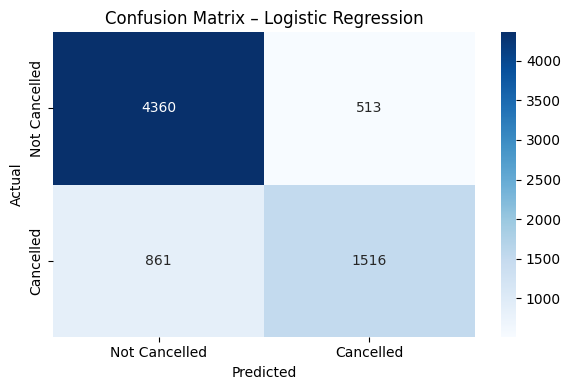

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Cancelled', 'Cancelled'],
    yticklabels=['Not Cancelled', 'Cancelled']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()


**Baseline Model Insights**

The Logistic Regression model achieved an overall accuracy of 81%, demonstrating strong baseline performance and clear interpretability. The model showed high effectiveness in identifying non-cancelled bookings (recall 0.89), but comparatively lower recall for cancelled bookings (0.64), indicating limitations in capturing more complex, non-linear cancellation patterns.

While this model provides a reliable and transparent benchmark, its linear decision boundary constrains its ability to fully model interactions between booking characteristics. To address this limitation and explore potential performance gains, the next stage of analysis applies Decision Tree modelling, which can capture non-linear relationships and feature interactions more explicitly.

# **Decision Tree Model**

Purpose

The Decision Tree model is introduced to capture non-linear relationships and feature interactions that Logistic Regression cannot model. It also provides intuitive, rule-based decision paths that support interpretability.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5  # controls overfitting; we can tune later
)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_pred_dt)


0.8337931034482758

In [ ]:
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4873
           1       0.77      0.71      0.74      2377

    accuracy                           0.83      7250
   macro avg       0.81      0.80      0.81      7250
weighted avg       0.83      0.83      0.83      7250



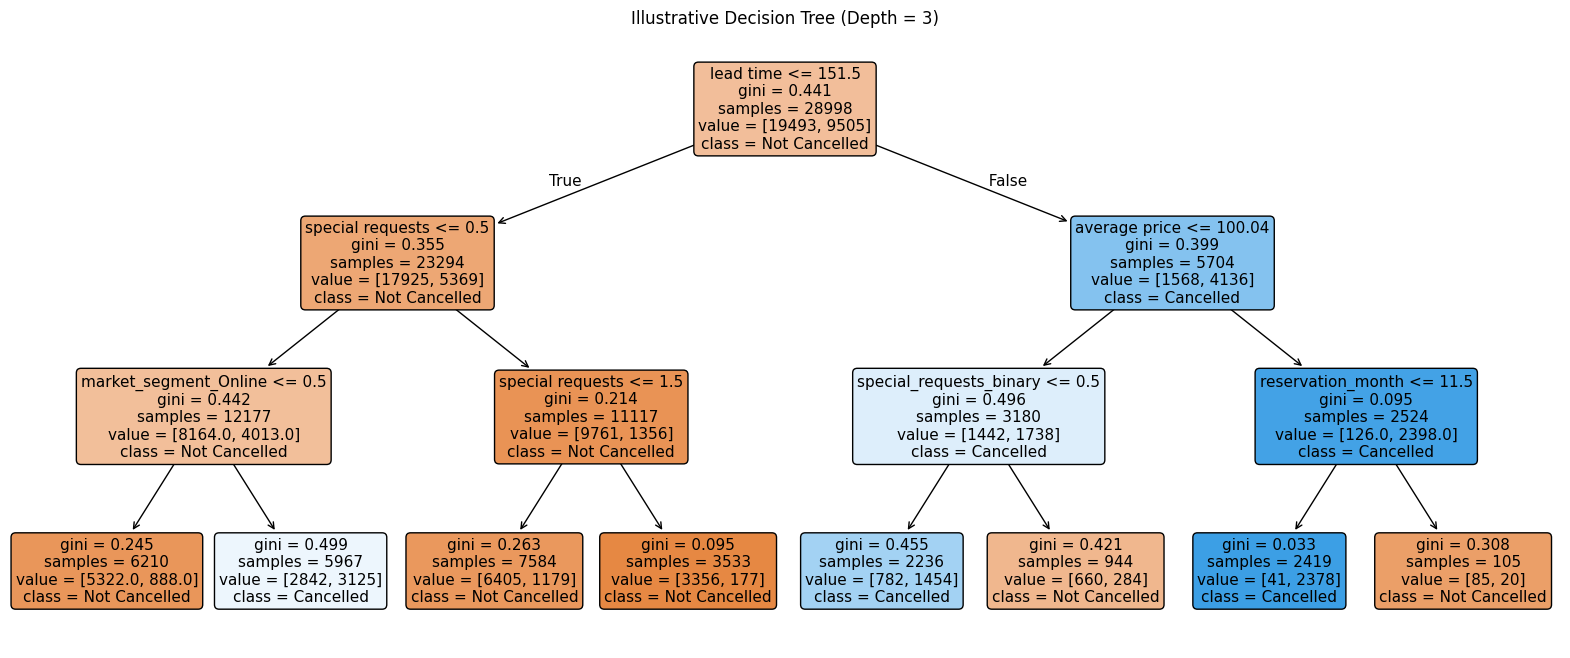

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

dt_vis = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
dt_vis.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(
    dt_vis,
    feature_names=X_encoded.columns,
    class_names=['Not Cancelled', 'Cancelled'],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Illustrative Decision Tree (Depth = 3)")
plt.show()


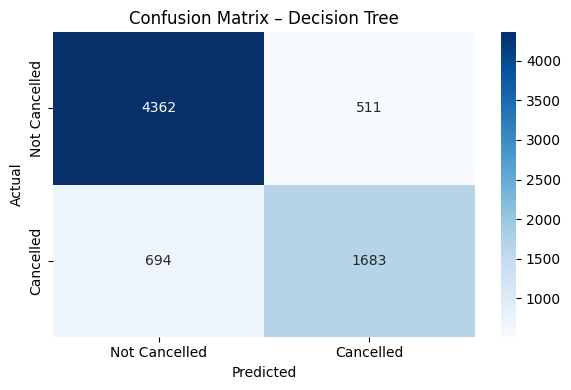

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Cancelled', 'Cancelled'],
    yticklabels=['Not Cancelled', 'Cancelled']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Decision Tree')
plt.tight_layout()
plt.show()


**Baseline Insights**

The Decision Tree model achieved an accuracy of 83.4%, improving on logistic regression by better capturing non-linear relationships in the data. The model showed stronger performance in identifying cancelled bookings (recall = 0.71) while maintaining high precision for non-cancelled bookings (precision = 0.86).

Key split variables included lead time, special requests, average price, and market segment, indicating their strong influence on cancellation behaviour. However, the model’s depth-driven structure increases sensitivity to training data, motivating the use of ensemble methods to enhance robustness.

# **Random Forest Model**

Purpose

This classifier was applied to improve predictive stability and reduce overfitting observed in the decision tree model. By aggregating multiple trees trained on bootstrapped samples with random feature selection, the model captures non-linear patterns while delivering more robust and generalisable predictions. Performance is evaluated on the same test set to allow direct comparison with earlier models.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_pred_rf)


0.8983448275862069

In [ ]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.91      0.94      0.93      4873
           1       0.86      0.82      0.84      2377

    accuracy                           0.90      7250
   macro avg       0.89      0.88      0.88      7250
weighted avg       0.90      0.90      0.90      7250



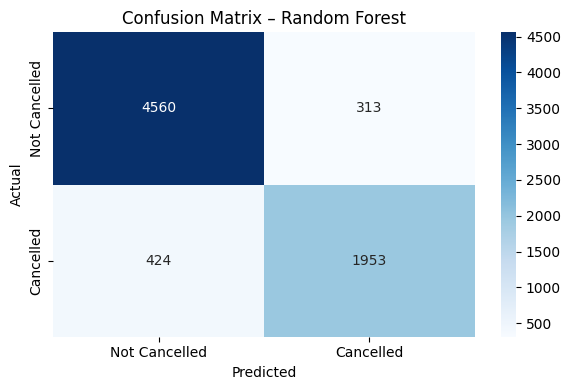

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Cancelled', 'Cancelled'],
    yticklabels=['Not Cancelled', 'Cancelled']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Random Forest')
plt.tight_layout()
plt.show()


**Baseline Insights**

The Random Forest model delivers a clear performance improvement, achieving 90% accuracy and a cancellation recall of 0.82, outperforming both Logistic Regression and the Decision Tree. The model correctly identifies 1,953 cancelled bookings, while keeping false positives low (313), indicating stronger risk discrimination.

Feature importance confirms lead time as the dominant driver (≈0.33), followed by average price (≈0.16) and seasonality effects. Overall, Random Forest provides a robust, high-performing baseline suitable for operational decision-making and serves as a strong benchmark for Gradient Boosting.

# **Gradient Boosting Model**

Purpose

This is applied to further improve predictive performance by sequentially correcting errors made by previous models. Unlike Random Forest, which averages many independent trees, Gradient Boosting focuses on hard-to-classify bookings, making it particularly effective for improving cancellation detection (recall).

Performance is evaluated on the same test set to ensure fair comparison with prior models

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_pred_gb)

print(classification_report(y_test, y_pred_gb))

confusion_matrix(y_test, y_pred_gb)


              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4873
           1       0.81      0.70      0.75      2377

    accuracy                           0.85      7250
   macro avg       0.84      0.81      0.82      7250
weighted avg       0.85      0.85      0.84      7250



array([[4485,  388],
       [ 715, 1662]])

**Baseline Insights**

Gradient Boosting achieved 85% accuracy, outperforming Logistic Regression (81%) and Decision Tree (83%), but underperforming Random Forest (≈90%).

The model improved cancellation detection with a 70% recall for cancelled bookings, indicating better sensitivity than simpler models, though still missing a portion of high-risk cases.

Overall, Gradient Boosting delivers strong, balanced performance, but Random Forest remains the most effective model for maximising cancellation prediction accuracy.

# **7. KEY BUINESS QUESTIONS ANSWERED**


**Question 1: What booking and customer characteristics influence cancellation behaviour?**

Purpose

The purpose of this analysis is to identify the key booking and customer characteristics that are associated with higher or lower cancellation risk. Understanding these behavioural drivers enables the business to anticipate cancellations earlier and design targeted interventions.

Approach

The Random Forest model was used to analyse historical booking data and estimate the relative importance of booking and customer features in predicting cancellation behaviour. Feature importance was examined from two complementary perspectives:

1. Factors that increase cancellation risk

2. Factors that are associated with lower cancellation risk

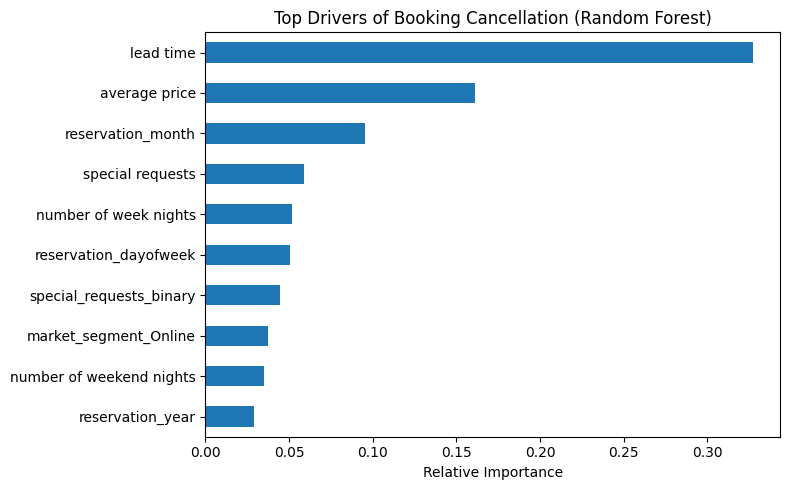

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_importance.head(10).plot(
    kind='barh',
    figsize=(8,5),
    title='Top Drivers of Booking Cancellation (Random Forest)'
)
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretation**

The Random Forest model shows that lead time is the strongest driver of booking cancellations, indicating that bookings made far in advance carry significantly higher risk. Average price and seasonality (reservation month) also contribute materially, suggesting that both financial commitment and timing influence customer reliability. Behavioural indicators such as special requests and length of stay further refine risk, highlighting that more engaged and structured bookings are generally more sta

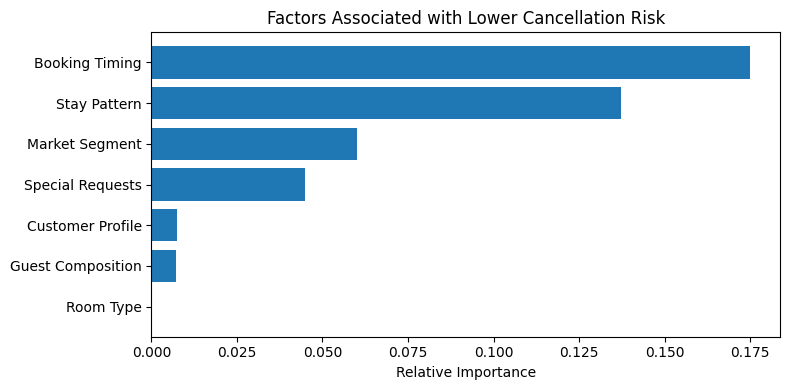

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importances
imp = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)

# Group features into business categories
groups = {
    "Room Type": imp[imp.index.str.contains("room_type")].sum(),
    "Customer Profile": imp[imp.index.str.contains("repeated|customer_profile")].sum(),
    "Market Segment": imp[imp.index.str.contains("market_segment")].sum(),
    "Guest Composition": imp[imp.index.str.contains("children")].sum(),
    "Special Requests": imp[imp.index.str.contains("special_requests")].sum(),
    "Stay Pattern": imp[imp.index.str.contains("week")].sum(),
    "Booking Timing": imp[imp.index.str.contains("reservation_")].sum()
}

agg_df = pd.Series(groups).sort_values()

# Plot
plt.figure(figsize=(8,4))
plt.barh(agg_df.index, agg_df.values)
plt.title("Factors Associated with Lower Cancellation Risk")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


**Interpretation**

Bookings with lower cancellation risk are most strongly associated with booking timing and stay pattern, indicating that guests who book closer to arrival and have more structured stays are significantly more likely to honour their reservations.
Market segment and special requests also play a moderate role, suggesting that more engaged and purpose-driven bookings tend to be more reliable.
In contrast, room type, guest composition, and customer profile contribute relatively little, implying that behavioural factors outweigh demographic characteristics in reducing cancellations.

**Question 2: Can booking outcomes be predicted reliably using historical data?**

Purpose

This analysis evaluates whether historical booking and customer data can be used to
predict cancellation outcomes with sufficient accuracy and reliability to support
operational decision-making.

Multiple classification models were trained and evaluated on the same test dataset.
Model performance was compared using standard classification metrics to assess
predictive accuracy and robustness.


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

results = []

for model, preds in models.items():
    results.append({
        "Model": model,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision (Cancelled)": precision_score(y_test, preds),
        "Recall (Cancelled)": recall_score(y_test, preds),
        "F1-score (Cancelled)": f1_score(y_test, preds)
    })

model_comparison = pd.DataFrame(results)
model_comparison


,Model,Accuracy,Precision (Cancelled),Recall (Cancelled),F1-score (Cancelled)
0,Logistic Regression,0.810483,0.747166,0.637779,0.688153
1,Decision Tree,0.833793,0.767092,0.708035,0.736382
2,Random Forest,0.898345,0.861871,0.821624,0.841266
3,Gradient Boosting,0.847862,0.810732,0.699201,0.750847


**Interpretation**

The results demonstrate that booking outcomes can be predicted reliably using historical data, with ensemble models particularly Random Forest,achieving strong accuracy and balanced recall for cancellation detection. This confirms the feasibility of using predictive models to support proactive cancellation management.

**Question 3: Which factors most strongly drive cancellation risk?**

Purpose

This question focuses on prioritisation, identifying the most influential drivers of cancellation risk. Unlike Question 1, which explored cancellation behaviour broadly, this analysis isolates the highest-impact factors to support targeted risk mitigation and operational focus.

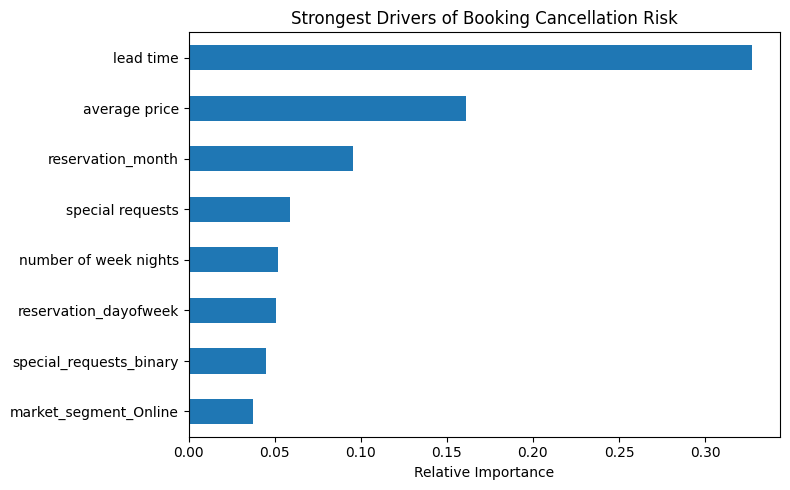

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_importance.head(8).plot(
    kind='barh',
    figsize=(8,5),
    title='Strongest Drivers of Booking Cancellation Risk'
)
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretation**

The model shows that lead time is by far the strongest driver of cancellation risk, indicating that bookings made far in advance are significantly more likely to be cancelled. Average price and seasonality (reservation month) are the next most influential factors, suggesting that higher prices and certain booking periods increase cancellation likelihood. Operational factors such as special requests and stay pattern (week nights) play a secondary role, while market segment has a relatively smaller impact. Overall, cancellation risk is driven primarily by when and how far ahead a booking is made, rather than by customer channel alone.

**Question 4: How can these insights be translated into actions to reduce cancellations and improve planning?**

Purpose

The objective of this question is to translate the predictive and explanatory insights from the modelling phase into practical, data-driven actions that can help reduce booking cancellations and support more effective operational and revenue planning.

**ANSWER**

The analysis indicates that lead time, pricing, and booking patterns are the strongest drivers of cancellation risk. To reduce cancellations, the hotel should implement tiered cancellation policies for long lead-time bookings, apply dynamic pricing controls to discourage speculative bookings and introduce early confirmation nudges for high-risk reservations.

Additionally, repeat customers and bookings with special requests show lower cancellation risk, suggesting opportunities to prioritise these segments through targeted incentives, loyalty benefits and flexible service offerings.

From a planning perspective, the predictive model enables early identification of high-risk bookings, allowing the hotel to proactively manage inventory, adjust overbooking strategies and improve demand forecasting, ultimately supporting more stable revenue and operational efficiency.

# **8. Conclusion**

This project demonstrates that booking cancellations can be reliably predicted using historical booking and customer data. Among the models evaluated, the Random Forest classifier delivered the strongest performance, achieving high overall accuracy and effectively identifying bookings at risk of cancellation. The analysis shows that cancellation behaviour is primarily driven by booking lead time, pricing, and timing-related factors, rather than customer demographics alone. These findings confirm that predictive analytics can support more proactive and data-driven cancellation management.

# **9. Limitations**

While the results are robust, several limitations should be noted:

- The analysis relies on historical booking data and does not capture external factors such as competitor pricing, economic conditions, or unexpected events.

- Model performance is dependent on the quality and representativeness of past data and may change as booking behaviour evolves.

- Feature importance reflects associations rather than causal relationships, and results should be interpreted accordingly.

# **10. Future Work**

Future enhancements could further strengthen the analysis by:

- Incorporating external data sources (e.g. holidays, local events, market conditions).

- Exploring time-aware or real-time prediction models to support dynamic decision-making.

- Implementing cost-sensitive modelling to explicitly balance the financial impact of false cancellations versus missed risks.

- Deploying the model into an operational dashboard to support live monitoring and intervention.